# Мультимодальная классификация покемонов: изображения + текст

В этом блокноте решается задача классификации основного типа покемона (`Type 1`) по двум модальностям:

- изображение покемона;
- текстовое описание, собранное из табличных признаков.

Мы реализуем два подхода на `TensorFlow / Keras`:

1. **CNN-модель**: сверточная ветвь для изображения + компактная текстовая ветвь.
2. **Transformer-модель**: patch-представление изображения + self-attention для изображения и текста.

В конце сравним модели на одинаковой тестовой выборке.

## План занятия

| Этап | Содержание |
|---|---|
| 1 | Загрузка датасета и анализ колонок |
| 2 | Формирование текстового описания |
| 3 | Подготовка изображений, меток и `tf.data.Dataset` |
| 4 | Мультимодальная CNN |
| 5 | Мультимодальный Transformer |
| 6 | Сравнение качества |

Целевая переменная:

$$
y = \mathrm{Type\ 1}.
$$

Модель получает два входа:

$$
f_\theta(\mathrm{image}, \mathrm{text}) \rightarrow \mathrm{pokemon\ type}.
$$

## 1. Установка и импорт библиотек

In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from datasets import load_dataset
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix


SEED = 42
DATASET_NAME = "JJMack/pokemon-classification-gen1-9"


def set_global_seed(seed):
    """
    Фиксирует генераторы случайных чисел для более воспроизводимого эксперимента.

    Аргументы:
        seed: целое число, начальное значение генераторов.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_global_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1779802744.048134 3432720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779802744.421120 3432720 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779802745.743339 3432720 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779802747.836483 3432720 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Загрузка датасета

Используем датасет `JJMack/pokemon-classification-gen1-9`.

В нем есть:

- `image_data` — изображение;
- `name` — имя покемона;
- `generation` — поколение;
- `Type 1` — основной тип, целевая переменная;
- `Type 2` — дополнительный тип;
- числовые характеристики: `HP`, `Attack`, `Defense`, `Sp.Attack`, `Sp.Defense`, `Speed`.

In [2]:
ds = load_dataset(DATASET_NAME)
ds

DatasetDict({
    train: Dataset({
        features: ['file_name', 'image_data', 'label', 'name', 'generation', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp.Attack', 'Sp.Defense', 'Speed', 'shiny'],
        num_rows: 13188
    })
    validation: Dataset({
        features: ['file_name', 'image_data', 'label', 'name', 'generation', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp.Attack', 'Sp.Defense', 'Speed', 'shiny'],
        num_rows: 2198
    })
    test: Dataset({
        features: ['file_name', 'image_data', 'label', 'name', 'generation', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp.Attack', 'Sp.Defense', 'Speed', 'shiny'],
        num_rows: 2530
    })
})

In [3]:
print(ds["train"].features)

print("Размер train:", len(ds["train"]))
print("Размер validation:", len(ds["validation"]))
print("Размер test:", len(ds["test"]))

{'file_name': Value('string'), 'image_data': Image(mode=None, decode=True), 'label': ClassLabel(names=['test', 'Bulbasaur', 'Ivysaur', 'Venusaur', 'Charmander', 'Charmeleon', 'Charizard', 'Squirtle', 'Wartortle', 'Blastoise', 'Caterpie', 'Metapod', 'Butterfree', 'Weedle', 'Kakuna', 'Beedrill', 'Pidgey', 'Pidgeotto', 'Pidgeot', 'Rattata', 'Raticate', 'Spearow', 'Fearow', 'Ekans', 'Arbok', 'Pikachu', 'Raichu', 'Sandshrew', 'Sandslash', 'Nidoran♀', 'Nidorina', 'Nidoqueen', 'Nidoran♂', 'Nidorino', 'Nidoking', 'Clefairy', 'Clefable', 'Vulpix', 'Ninetales', 'Jigglypuff', 'Wigglytuff', 'Zubat', 'Golbat', 'Oddish', 'Gloom', 'Vileplume', 'Paras', 'Parasect', 'Venonat', 'Venomoth', 'Diglett', 'Dugtrio', 'Meowth', 'Persian', 'Psyduck', 'Golduck', 'Mankey', 'Primeape', 'Growlithe', 'Arcanine', 'Poliwag', 'Poliwhirl', 'Poliwrath', 'Abra', 'Kadabra', 'Alakazam', 'Machop', 'Machoke', 'Machamp', 'Bellsprout', 'Weepinbell', 'Victreebel', 'Tentacool', 'Tentacruel', 'Geodude', 'Graveler', 'Golem', 'Ponyt

## 3. Баланс классов

Классы покемонов распределены неравномерно. Поэтому помимо accuracy будем смотреть `macro F1`: эта метрика усредняет качество по классам и чувствительнее к редким типам.

In [4]:
def show_class_balance(dataset_dict, target_column="Type 1"):
    """
    Печатает распределение классов для каждого split датасета.

    Аргументы:
        dataset_dict: объект DatasetDict.
        target_column: название колонки с целевой переменной.
    """
    for split_name in dataset_dict.keys():
        counts = Counter(dataset_dict[split_name][target_column])
        total = sum(counts.values())
        proportions = {label: round(count / total, 3) for label, count in sorted(counts.items())}

        print(split_name)
        print(proportions)
        print()


show_class_balance(ds)

train
{'Bug': 0.078, 'Dark': 0.035, 'Dragon': 0.034, 'Electric': 0.056, 'Fairy': 0.025, 'Fighting': 0.038, 'Fire': 0.07, 'Flying': 0.005, 'Ghost': 0.033, 'Grass': 0.095, 'Ground': 0.04, 'Ice': 0.03, 'Normal': 0.126, 'Poison': 0.043, 'Psychic': 0.061, 'Rock': 0.055, 'Steel': 0.029, 'Water': 0.149}

validation
{'Bug': 0.077, 'Dark': 0.034, 'Dragon': 0.033, 'Electric': 0.056, 'Fairy': 0.024, 'Fighting': 0.039, 'Fire': 0.071, 'Flying': 0.005, 'Ghost': 0.033, 'Grass': 0.093, 'Ground': 0.039, 'Ice': 0.031, 'Normal': 0.129, 'Poison': 0.041, 'Psychic': 0.062, 'Rock': 0.054, 'Steel': 0.028, 'Water': 0.152}

test
{'Bug': 0.079, 'Dark': 0.038, 'Dragon': 0.035, 'Electric': 0.056, 'Fairy': 0.028, 'Fighting': 0.037, 'Fire': 0.068, 'Flying': 0.006, 'Ghost': 0.031, 'Grass': 0.1, 'Ground': 0.04, 'Ice': 0.03, 'Normal': 0.118, 'Poison': 0.043, 'Psychic': 0.059, 'Rock': 0.057, 'Steel': 0.032, 'Water': 0.141}



## 4. Формирование текстового описания

Датасет не содержит длинного естественного описания покемона, поэтому создадим короткий текст из доступных табличных признаков.

Важно: текстовая модальность не заменяет изображение. Она дает модели дополнительную информацию о характеристиках объекта.

Целевой класс: Grass
Текстовое описание:
Pokemon name: Gloom. Generation: 1. Secondary type: Poison. HP: 60. Attack: 65. Defense: 70. Special attack: 85. Special defense: 75. Speed: 40.


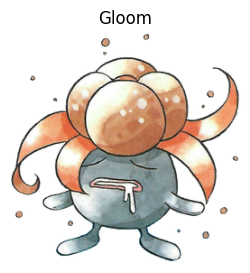

In [5]:
def make_text_description(row):
    """
    Создает текстовое описание одного покемона из табличных признаков.

    Аргументы:
        row: словарь или строка DataFrame с полями датасета.

    Возвращает:
        Строку с компактным описанием покемона.
    """
    type_2 = row["Type 2"] if row["Type 2"] is not None else "None"

    return (
        f"Pokemon name: {row['name']}. "
        f"Generation: {row['generation']}. "
        f"Secondary type: {type_2}. "
        f"HP: {row['HP']}. Attack: {row['Attack']}. Defense: {row['Defense']}. "
        f"Special attack: {row['Sp.Attack']}. Special defense: {row['Sp.Defense']}. "
        f"Speed: {row['Speed']}."
    )


example = ds["train"][0]
print("Целевой класс:", example["Type 1"])
print("Текстовое описание:")
print(make_text_description(example))

plt.figure(figsize=(3, 3))
plt.imshow(example["image_data"])
plt.axis("off")
plt.title(example["name"])
plt.show()

## 5. Подготовка массивов

Для обеих моделей используем один и тот же препроцессинг:

- изображение приводим к размеру `96 x 96`;
- пиксели переводим в диапазон `[0, 1]`;
- класс `Type 1` кодируем числом;
- текст оставляем строкой, потому что слой `TextVectorization` будет частью Keras-пайплайна.

In [6]:
IMG_SIZE = (96, 96)
IMG_SHAPE = (96, 96, 3)
MAX_TEXT_TOKENS = 40
TEXT_VOCAB_SIZE = 1000

BATCH_SIZE = 64
EPOCHS = 8
LEARNING_RATE = 3e-4


class_names = sorted(set(ds["train"]["Type 1"]))
label_to_id = {label: index for index, label in enumerate(class_names)}
id_to_label = {index: label for label, index in label_to_id.items()}
NUM_CLASSES = len(class_names)

print("Количество классов:", NUM_CLASSES)
print(label_to_id)

Количество классов: 18
{'Bug': 0, 'Dark': 1, 'Dragon': 2, 'Electric': 3, 'Fairy': 4, 'Fighting': 5, 'Fire': 6, 'Flying': 7, 'Ghost': 8, 'Grass': 9, 'Ground': 10, 'Ice': 11, 'Normal': 12, 'Poison': 13, 'Psychic': 14, 'Rock': 15, 'Steel': 16, 'Water': 17}


In [7]:
def prepare_split(dataset_split):
    """
    Преобразует split Hugging Face Dataset в массивы для TensorFlow.

    Аргументы:
        dataset_split: один split датасета, например ds["train"].

    Возвращает:
        images: numpy-массив изображений, shape = (N, 96, 96, 3).
        texts: numpy-массив строковых описаний, shape = (N,).
        labels: numpy-массив числовых классов, shape = (N,).
    """
    images = []
    texts = []
    labels = []

    for item in dataset_split:
        image = item["image_data"].convert("RGB").resize(IMG_SIZE)
        image = np.asarray(image, dtype="float32") / 255.0

        images.append(image)
        texts.append(make_text_description(item))
        labels.append(label_to_id[item["Type 1"]])

    return (
        np.asarray(images, dtype="float32"),
        np.asarray(texts, dtype=str),
        np.asarray(labels, dtype="int32"),
    )


x_train_img, x_train_text, y_train = prepare_split(ds["train"])
x_val_img, x_val_text, y_val = prepare_split(ds["validation"])
x_test_img, x_test_text, y_test = prepare_split(ds["test"])

print("Train images:", x_train_img.shape)
print("Train texts:", x_train_text.shape)
print("Train labels:", y_train.shape)

/home/dmitry/.local/lib/python3.12/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train images: (13188, 96, 96, 3)
Train texts: (13188,)
Train labels: (13188,)


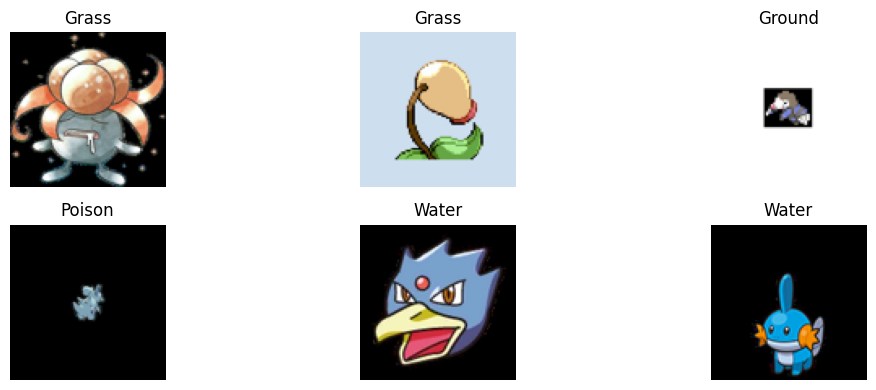

In [8]:
plt.figure(figsize=(12, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train_img[i])
    plt.title(f"{id_to_label[y_train[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. `tf.data.Dataset`

Модель будет получать два входа:

```python
{
    "image_input": image,
    "text_input": text
}
```

Такой формат хорошо подходит для Keras Functional API.

In [9]:
def make_dataset(images, texts, labels, batch_size, shuffle=False):
    """
    Создает batched tf.data.Dataset для мультимодальной модели.

    Аргументы:
        images: массив изображений.
        texts: массив текстовых описаний.
        labels: массив числовых классов.
        batch_size: размер батча.
        shuffle: перемешивать ли данные.

    Возвращает:
        tf.data.Dataset.
    """
    features = {
        "image_input": images,
        "text_input": texts,
    }

    dataset = tf.data.Dataset.from_tensor_slices((features, labels))

    if shuffle:
        dataset = dataset.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(x_train_img, x_train_text, y_train, BATCH_SIZE, shuffle=True)
val_ds = make_dataset(x_val_img, x_val_text, y_val, BATCH_SIZE)
test_ds = make_dataset(x_test_img, x_test_text, y_test, BATCH_SIZE)

for features, labels in train_ds.take(1):
    print(features["image_input"].shape)
    print(features["text_input"].shape)
    print(labels.shape)

W0000 00:00:1779802775.350128 3432720 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779802775.533297 3432720 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


(64, 96, 96, 3)
(64,)
(64,)


## 7. Текстовая векторизация

Слой `TextVectorization` строит словарь по обучающей выборке и переводит строку в последовательность токенов.

Этот слой будет использоваться внутри обеих моделей, поэтому токенизация станет частью вычислительного графа Keras.

In [10]:
text_vectorizer = layers.TextVectorization(
    max_tokens=TEXT_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_TEXT_TOKENS,
    name="text_vectorizer",
)

text_vectorizer.adapt(x_train_text)

print("Размер словаря:", len(text_vectorizer.get_vocabulary()))
print("Пример токенов:")
print(text_vectorizer(x_train_text[:1]).numpy()[0])

Размер словаря: 1000
Пример токенов:
[  8   9 375  11  21   7   5  45  10  14   4  15   3  16   2   4  25   2
   3  24   6  17   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]


## 8. Общие callbacks

Для обеих моделей используем одинаковую стратегию обучения:

- `EarlyStopping` возвращает лучшие веса по `val_loss`;
- `ReduceLROnPlateau` уменьшает learning rate при остановке прогресса.

In [11]:
def make_callbacks():
    """
    Создает callbacks для обучения моделей.

    Возвращает:
        Список Keras callbacks.
    """
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

# Часть A. Мультимодальная CNN

CNN хорошо подходит для изображений, потому что локальные фильтры выделяют края, формы и повторяющиеся визуальные паттерны.

В этой модели:

- изображение проходит через несколько `Conv2D` блоков;
- текст проходит через `TextVectorization`, `Embedding` и усреднение;
- признаки двух модальностей объединяются через `Concatenate`.

In [12]:
def build_multimodal_cnn_model():
    """
    Строит мультимодальную CNN-модель.

    Возвращает:
        Скомпилированную keras.Model с двумя входами: image_input и text_input.
    """
    image_input = keras.Input(shape=IMG_SHAPE, name="image_input")
    text_input = keras.Input(shape=(), dtype=tf.string, name="text_input")

    image_aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
        ],
        name="image_augmentation",
    )

    x_img = image_aug(image_input)
    x_img = layers.Conv2D(32, 3, padding="same", activation="relu", name="cnn_conv_1")(x_img)
    x_img = layers.BatchNormalization(name="cnn_bn_1")(x_img)
    x_img = layers.MaxPooling2D(name="cnn_pool_1")(x_img)

    x_img = layers.Conv2D(64, 3, padding="same", activation="relu", name="cnn_conv_2")(x_img)
    x_img = layers.BatchNormalization(name="cnn_bn_2")(x_img)
    x_img = layers.MaxPooling2D(name="cnn_pool_2")(x_img)

    x_img = layers.Conv2D(128, 3, padding="same", activation="relu", name="cnn_conv_3")(x_img)
    x_img = layers.BatchNormalization(name="cnn_bn_3")(x_img)
    x_img = layers.GlobalAveragePooling2D(name="cnn_global_pool")(x_img)
    x_img = layers.Dense(128, activation="relu", name="cnn_image_features")(x_img)

    token_ids = text_vectorizer(text_input)
    x_text = layers.Embedding(TEXT_VOCAB_SIZE, 64, mask_zero=True, name="cnn_text_embedding")(token_ids)
    x_text = layers.GlobalAveragePooling1D(name="cnn_text_pool")(x_text)
    x_text = layers.Dense(64, activation="relu", name="cnn_text_features")(x_text)

    x = layers.Concatenate(name="cnn_fusion")([x_img, x_text])
    x = layers.Dropout(0.3, name="cnn_fusion_dropout")(x)
    x = layers.Dense(128, activation="relu", name="cnn_joint_dense")(x)
    x = layers.Dropout(0.3, name="cnn_joint_dropout")(x)

    output = layers.Dense(NUM_CLASSES, activation="softmax", name="class_probabilities")(x)

    model = keras.Model(
        inputs={"image_input": image_input, "text_input": text_input},
        outputs=output,
        name="multimodal_cnn_classifier",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


cnn_model = build_multimodal_cnn_model()
cnn_model.summary()

Model: "multimodal_cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_augmentation  │ (None, 96, 96, 3) │          0 │ image_input[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_1 (Conv2D) │ (None, 96, 96,    │        896 │ image_augmentati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_1            │ (None, 96, 96,    │        128 │ cnn_conv_1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool_1          │ (None, 48, 48,    │          0 │ cnn_bn_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_2 (Conv2D) │ (None, 48, 48,    │     18,496 │ cnn_pool_1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_2            │ (None, 48, 48,    │        256 │ cnn_conv_2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool_2          │ (None, 24, 24,    │          0 │ cnn_bn_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_3 (Conv2D) │ (None, 24, 24,    │     73,856 │ cnn_pool_2[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorizer     │ (None, 40)        │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_3            │ (None, 24, 24,    │        512 │ cnn_conv_3[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_text_embedding  │ (None, 40, 64)    │     64,000 │ text_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 40)        │          0 │ text_vectorizer[… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_pool     │ (None, 128)       │          0 │ cnn_bn_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_text_pool       │ (None, 64)        │          0 │ cnn_text_embeddi… │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_image_features  │ (None, 128)       │     16,512 │ cnn_global_pool[

 Total params: 205,842 (804.07 KB)

 Trainable params: 205,394 (802.32 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks(),
)

Epoch 1/8


I0000 00:00:1779802784.049653 3432853 cuda_dnn.cc:461] Loaded cuDNN version 91900


207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.2121 - loss: 2.6362 - val_accuracy: 0.1297 - val_loss: 2.7655 - learning_rate: 3.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.2552 - loss: 2.4952 - val_accuracy: 0.1638 - val_loss: 2.6786 - learning_rate: 3.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.2781 - loss: 2.3806 - val_accuracy: 0.2780 - val_loss: 2.2970 - learning_rate: 3.0000e-04
Epoch 4/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.3344 - loss: 2.1836 - val_accuracy: 0.4145 - val_loss: 1.9241 - learning_rate: 3.0000e-04
Epoch 5/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.4179 - loss: 1.8786 - val_accuracy: 0.4859 - val_loss: 1.6407 - learning_rate: 3.0000e-04
Epoch 6/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5100 - loss: 1.5954 - val_accuracy: 0.6374 - val_loss: 1.2882 - learning_rate: 3.0000e-04
Epoch 7/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5970 - 

# Часть B. Мультимодальный Transformer

Transformer использует self-attention:

$$
\mathrm{Attention}(Q, K, V) =
\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

Для изображения применим идею Vision Transformer:

1. разобьем изображение на патчи;
2. превратим патчи в последовательность векторов;
3. добавим позиционные embeddings;
4. обработаем последовательность self-attention.

Для текста используем похожий encoder-блок.

In [21]:
TRANSFORMER_DIM = 96
TRANSFORMER_HEADS = 4
TRANSFORMER_FF_DIM = 192
PATCH_SIZE = 12
NUM_PATCHES = (IMG_SIZE[0] // PATCH_SIZE) * (IMG_SIZE[1] // PATCH_SIZE)


def add_position_embeddings(sequence, sequence_length, embed_dim, name):
    """
    Добавляет обучаемые позиционные embeddings, используя только Keras API 
    для сохранения динамического размера батча.
    """
    # 1. Создаем константный Keras-вход для позиций (от 0 до sequence_length)
    positions = keras.Input(shape=(sequence_length,), dtype="int32", name=f"{name}_pos_input")
    
    # 2. Создаем и вызываем слой Embedding
    position_embeddings = layers.Embedding(
        input_dim=sequence_length,
        output_dim=embed_dim,
        name=f"{name}_position_embedding",
    )(positions) # Форма: (batch, sequence_length, embed_dim)
    
    # Чтобы не плодить лишние входы в модель, генерируем индексы прямо на лету 
    # через Lambda-слой, который правильно транслирует батч
    pos_indices = layers.Lambda(
        lambda x: tf.tile(tf.expand_dims(tf.range(sequence_length), 0), [tf.shape(x)[0], 1]),
        name=f"{name}_pos_indices"
    )(sequence)
    
    # Применяем слой эмбеддингов к сгенерированным индексам
    pos_embeds = layers.Embedding(
        input_dim=sequence_length,
        output_dim=embed_dim,
        name=f"{name}_position_embedding",
    )(pos_indices)

    return layers.Add(name=f"{name}_add_position")([sequence, pos_embeds])


def transformer_encoder_block(x, attention_mask, embed_dim, num_heads, ff_dim, dropout_rate, name):
    """
    Добавляет один encoder-блок Transformer.

    Аргументы:
        x: последовательность токенов формы (batch, seq_len, embed_dim).
        attention_mask: маска attention или None.
        embed_dim: размерность токена.
        num_heads: количество голов attention.
        ff_dim: размерность внутреннего Dense-слоя.
        dropout_rate: вероятность dropout.
        name: префикс имен слоев.

    Возвращает:
        Последовательность токенов той же формы.
    """
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
        name=f"{name}_mha",
    )(x, x, attention_mask=attention_mask)

    x = layers.Add(name=f"{name}_attn_residual")([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_attn_norm")(x)

    ffn = layers.Dense(ff_dim, activation="gelu", name=f"{name}_ffn_1")(x)
    ffn = layers.Dropout(dropout_rate, name=f"{name}_ffn_dropout")(ffn)
    ffn = layers.Dense(embed_dim, name=f"{name}_ffn_2")(ffn)

    x = layers.Add(name=f"{name}_ffn_residual")([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ffn_norm")(x)

    return x

In [22]:
def build_multimodal_transformer_model():
    """
    Строит мультимодальную Transformer-модель.

    Возвращает:
        Скомпилированную keras.Model с двумя входами: image_input и text_input.
    """
    image_input = keras.Input(shape=IMG_SHAPE, name="image_input")
    text_input = keras.Input(shape=(), dtype=tf.string, name="text_input")

    image_aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
        ],
        name="transformer_image_augmentation",
    )

    x_img = image_aug(image_input)
    x_img = layers.Conv2D(
        filters=TRANSFORMER_DIM,
        kernel_size=PATCH_SIZE,
        strides=PATCH_SIZE,
        padding="valid",
        name="image_patch_projection",
    )(x_img)
    x_img = layers.Reshape((NUM_PATCHES, TRANSFORMER_DIM), name="image_patch_sequence")(x_img)
    x_img = add_position_embeddings(x_img, NUM_PATCHES, TRANSFORMER_DIM, name="image")
    x_img = transformer_encoder_block(
        x_img,
        attention_mask=None,
        embed_dim=TRANSFORMER_DIM,
        num_heads=TRANSFORMER_HEADS,
        ff_dim=TRANSFORMER_FF_DIM,
        dropout_rate=0.2,
        name="image_transformer_1",
    )
    x_img = layers.GlobalAveragePooling1D(name="image_transformer_pool")(x_img)

    token_ids = text_vectorizer(text_input)
    text_mask = layers.Lambda(
        lambda ids: tf.cast(ids[:, tf.newaxis, :], tf.bool),
        name="text_attention_mask",
    )(token_ids)

    x_text = layers.Embedding(TEXT_VOCAB_SIZE, TRANSFORMER_DIM, mask_zero=False, name="text_embedding")(token_ids)
    x_text = add_position_embeddings(x_text, MAX_TEXT_TOKENS, TRANSFORMER_DIM, name="text")
    x_text = transformer_encoder_block(
        x_text,
        attention_mask=text_mask,
        embed_dim=TRANSFORMER_DIM,
        num_heads=TRANSFORMER_HEADS,
        ff_dim=TRANSFORMER_FF_DIM,
        dropout_rate=0.2,
        name="text_transformer_1",
    )
    x_text = layers.GlobalAveragePooling1D(name="text_transformer_pool")(x_text)

    x = layers.Concatenate(name="transformer_fusion")([x_img, x_text])
    x = layers.Dropout(0.3, name="transformer_fusion_dropout")(x)
    x = layers.Dense(128, activation="gelu", name="transformer_joint_dense")(x)
    x = layers.Dropout(0.3, name="transformer_joint_dropout")(x)

    output = layers.Dense(NUM_CLASSES, activation="softmax", name="class_probabilities")(x)

    model = keras.Model(
        inputs={"image_input": image_input, "text_input": text_input},
        outputs=output,
        name="multimodal_transformer_classifier",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


tf.keras.backend.clear_session()
transformer_model = build_multimodal_transformer_model()
transformer_model.summary()

Model: "multimodal_transformer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_image_… │ (None, 96, 96, 3) │          0 │ image_input[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_patch_projec… │ (None, 8, 8, 96)  │     41,568 │ transformer_imag… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorizer     │ (None, 40)        │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_patch_sequen… │ (None, 64, 96)    │          0 │ image_patch_proj… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 40, 96)    │     96,000 │ text_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_pos_indices   │ (None, 64)        │          0 │ image_patch_sequ… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_pos_indices    │ (None, 40)        │          0 │ text_embedding[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_position_emb… │ (None, 64, 96)    │      6,144 │ image_pos_indice… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_position_embe… │ (None, 40, 96)    │      3,840 │ text_pos_indices… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_add_position  │ (None, 64, 96)    │          0 │ image_patch_sequ… │
│ (Add)               │                   │            │ image_position_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_add_position   │ (None, 40, 96)    │          0 │ text_embedding[0… │
│ (Add)               │                   │            │ text_position_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_attention_mask │ (None, 1, 40)     │          0 │ text_vectorizer[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_transformer_… │ (None, 64, 96)    │     37,248 │ image_add_positi… │
│ (MultiHeadAttentio… │                   │            │ image_add_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_transformer_1… │ (None, 40, 96)    │     37,248 │ text_add_positio… │
│ (MultiHeadAttentio… │                   │            │ text_add_positio… │
│                     │                   │            │ text_attention_m… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 324,146 (1.24 MB)

 Trainable params: 324,146 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
transformer_history = transformer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks(),
)

Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.1784 - loss: 2.6768 - val_accuracy: 0.2598 - val_loss: 2.4665 - learning_rate: 3.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.3616 - loss: 2.0888 - val_accuracy: 0.6242 - val_loss: 1.1571 - learning_rate: 3.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.8529 - loss: 0.5365 - val_accuracy: 0.9604 - val_loss: 0.1327 - learning_rate: 3.0000e-04
Epoch 4/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9493 - loss: 0.1943 - val_accuracy: 0.9777 - val_loss: 0.0801 - learning_rate: 3.0000e-04
Epoch 5/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9604 - loss: 0.1436 - val_accuracy: 0.9791 - val_loss: 0.0638 - learning_rate: 3.0000e-04
Epoch 6/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9697 - loss: 0.1075 - val_accuracy: 0.9850 - val_loss: 0.0455 - learning_rate: 3.0000e-04
Epoch 7/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accurac

## 9. Графики обучения

Сравним динамику обучения двух моделей.

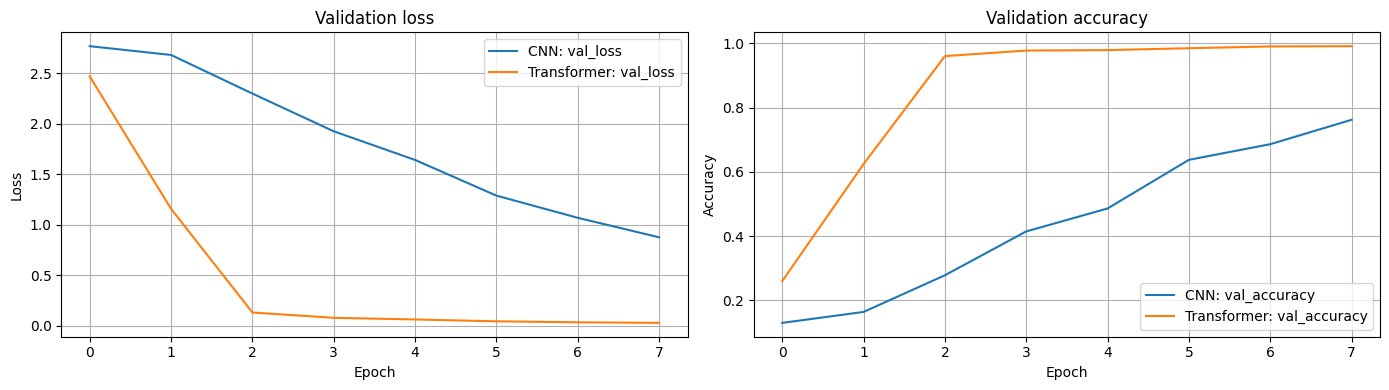

In [24]:
def plot_histories(histories):
    """
    Строит графики loss и accuracy для нескольких моделей.

    Аргументы:
        histories: словарь {название модели: объект History}.
    """
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    for model_name, history in histories.items():
        plt.plot(history.history["val_loss"], label=f"{model_name}: val_loss")
    plt.title("Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    for model_name, history in histories.items():
        plt.plot(history.history["val_accuracy"], label=f"{model_name}: val_accuracy")
    plt.title("Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_histories({
    "CNN": cnn_history,
    "Transformer": transformer_history,
})

## 10. Оценка моделей

Для сравнения используем:

- `accuracy`;
- `macro F1`;
- `weighted F1`;
- количество обучаемых параметров.

`macro F1` особенно важен, потому что редкие классы не должны теряться на фоне частых.

In [25]:
def evaluate_model(model, dataset, y_true, model_name):
    """
    Оценивает модель на тестовой выборке.

    Аргументы:
        model: обученная keras.Model.
        dataset: tf.data.Dataset для предсказания.
        y_true: истинные метки.
        model_name: название модели для таблицы результатов.

    Возвращает:
        result: словарь с основными метриками.
        y_pred: массив предсказанных классов.
    """
    probabilities = model.predict(dataset, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)

    result = {
        "model": model_name,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "parameters": model.count_params(),
    }

    return result, y_pred


cnn_result, cnn_pred = evaluate_model(cnn_model, test_ds, y_test, "CNN")
transformer_result, transformer_pred = evaluate_model(transformer_model, test_ds, y_test, "Transformer")

comparison = pd.DataFrame([cnn_result, transformer_result]).sort_values("macro_f1", ascending=False)
comparison

,model,test_accuracy,macro_f1,weighted_f1,parameters
1,Transformer,0.980632,0.979709,0.980581,324146
0,CNN,0.705929,0.565822,0.693083,205842


In [26]:
best_model_name = comparison.iloc[0]["model"]
print(f"Лучшая модель по macro F1: {best_model_name}")

print("CNN")
print(classification_report(y_test, cnn_pred, target_names=class_names, digits=3))

print("Transformer")
print(classification_report(y_test, transformer_pred, target_names=class_names, digits=3))

Лучшая модель по macro F1: Transformer
CNN
              precision    recall  f1-score   support

         Bug      0.746     0.910     0.820       200
        Dark      0.558     0.495     0.525        97
      Dragon      0.559     0.213     0.309        89
    Electric      0.518     0.711     0.599       142
       Fairy      0.537     0.629     0.579        70
    Fighting      0.452     0.301     0.361        93
        Fire      0.711     0.867     0.781       173
      Flying      0.000     0.000     0.000        15
       Ghost      0.750     0.190     0.303        79
       Grass      0.865     0.783     0.822       254
      Ground      0.724     0.206     0.321       102
         Ice      0.339     0.737     0.465        76
      Normal      0.971     0.890     0.928       299
      Poison      0.677     0.573     0.621       110
     Psychic      0.457     0.893     0.605       149
        Rock      0.850     0.708     0.773       144
       Steel      0.703     0.321     

/home/dmitry/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dmitry/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dmitry/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 11. Матрицы ошибок

Матрица ошибок показывает, какие типы модель путает чаще всего.

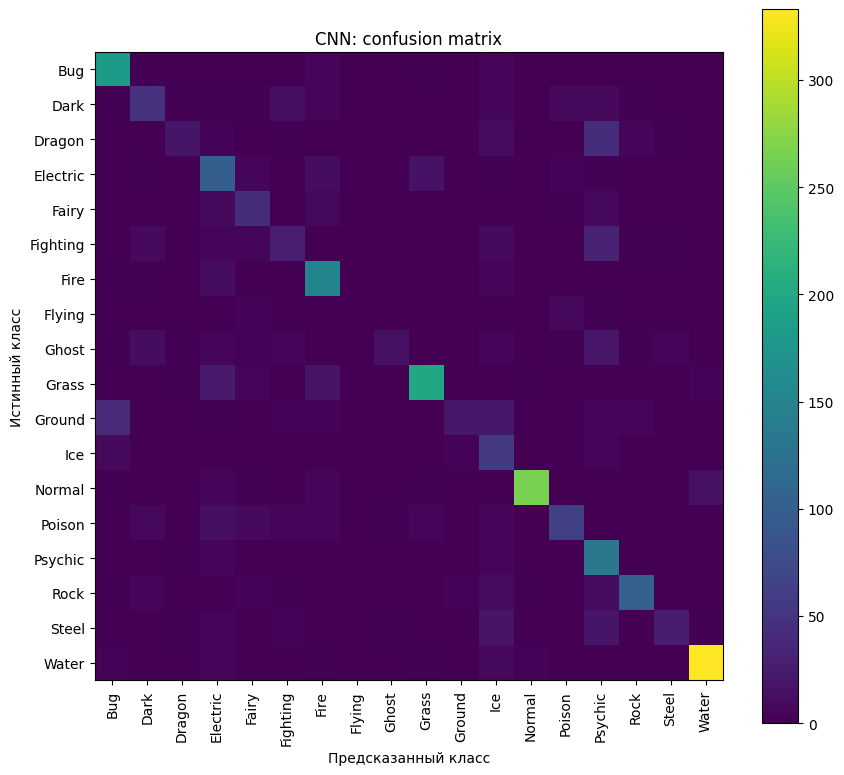

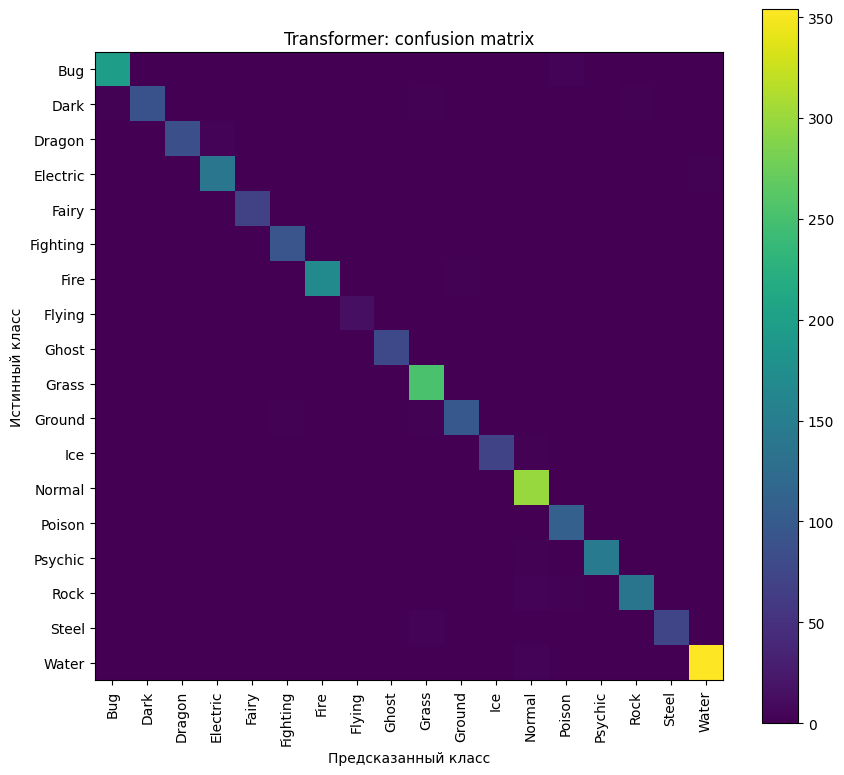

In [27]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Рисует confusion matrix.

    Аргументы:
        y_true: истинные метки.
        y_pred: предсказанные метки.
        labels: названия классов.
        title: заголовок графика.
    """
    matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(9, 8))
    plt.imshow(matrix)
    plt.title(title)
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.xticks(np.arange(len(labels)), labels, rotation=90)
    plt.yticks(np.arange(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, cnn_pred, class_names, "CNN: confusion matrix")
plot_confusion_matrix(y_test, transformer_pred, class_names, "Transformer: confusion matrix")

## 12. Визуальная проверка предсказаний

Посмотрим несколько примеров из тестовой выборки.

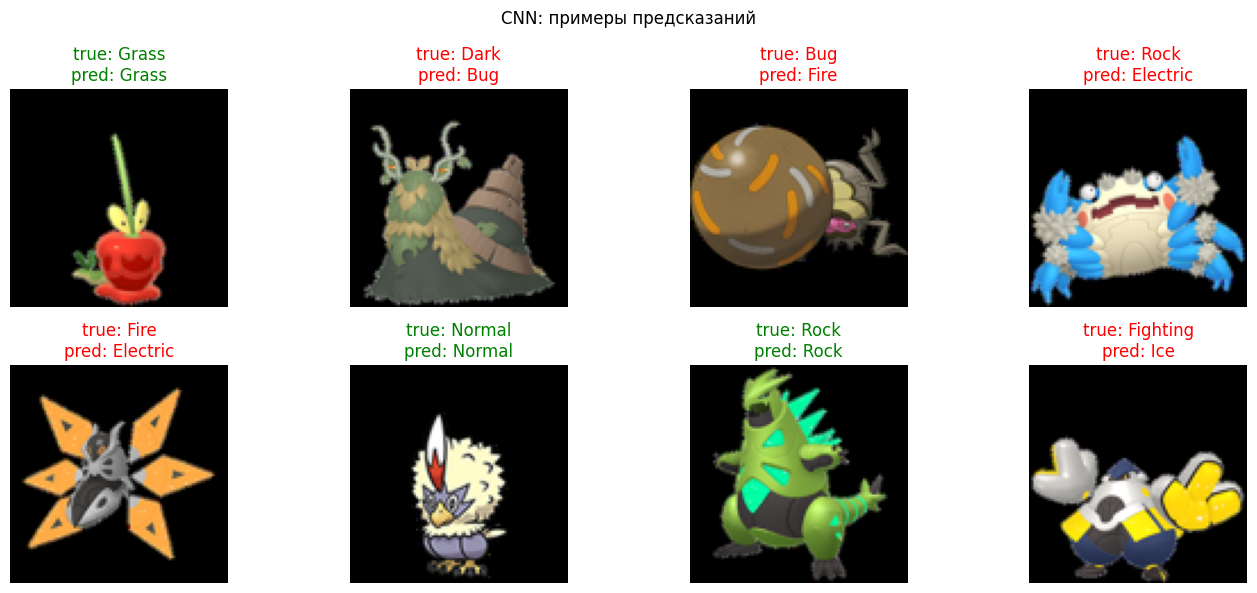

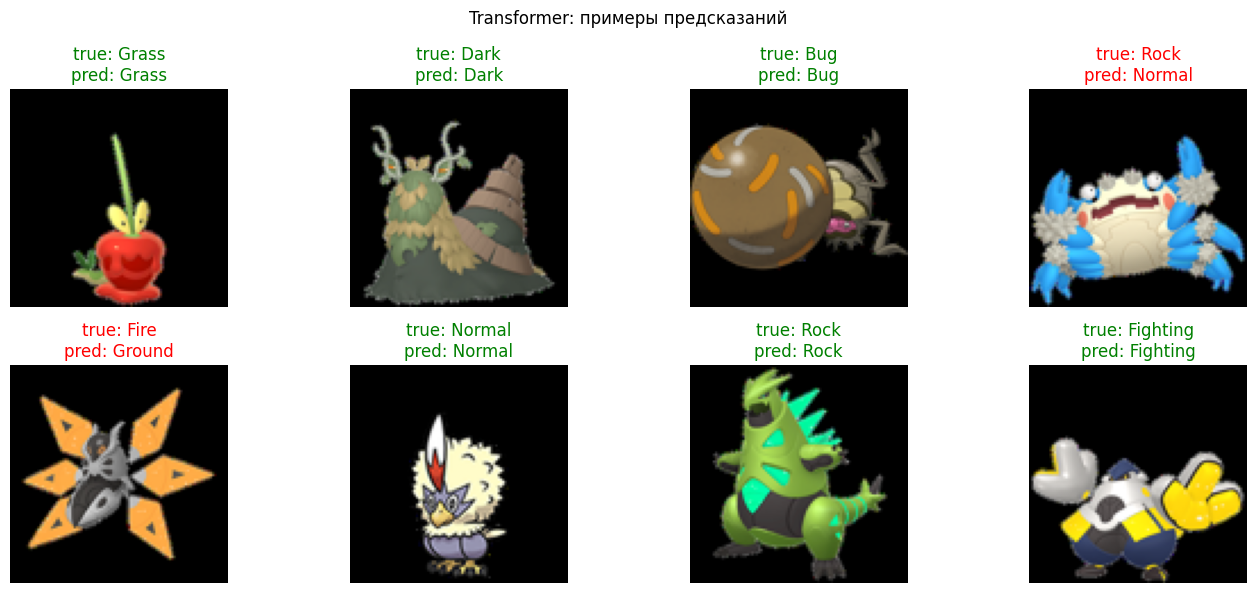

In [28]:
def show_predictions(images, y_true, y_pred, title, n=8):
    """
    Показывает изображения с истинным и предсказанным классом.

    Аргументы:
        images: массив изображений.
        y_true: истинные метки.
        y_pred: предсказанные метки.
        title: заголовок блока.
        n: количество примеров.
    """
    plt.figure(figsize=(14, 6))

    for i in range(n):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])

        true_label = id_to_label[int(y_true[i])]
        predicted_label = id_to_label[int(y_pred[i])]
        color = "green" if true_label == predicted_label else "red"

        plt.title(f"true: {true_label}\npred: {predicted_label}", color=color)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_predictions(x_test_img, y_test, cnn_pred, "CNN: примеры предсказаний")
show_predictions(x_test_img, y_test, transformer_pred, "Transformer: примеры предсказаний")

## 13. Итоговое сравнение

Обычно CNN сильна как базовая модель для изображений: она использует локальность пикселей и хорошо работает даже при умеренном объеме данных.

Transformer потенциально гибче: он может моделировать отношения между удаленными патчами изображения и токенами текста. Но для небольших датасетов Transformer часто требует больше данных, регуляризации или предобучения.

Практический вывод нужно делать по таблице `comparison`:

- если выше `macro_f1`, модель лучше справляется со всеми классами в среднем;
- если выше `weighted_f1`, модель лучше с учетом частоты классов;
- если качество близкое, более компактная модель может быть предпочтительнее.

In [29]:
comparison

,model,test_accuracy,macro_f1,weighted_f1,parameters
1,Transformer,0.980632,0.979709,0.980581,324146
0,CNN,0.705929,0.565822,0.693083,205842


## 14. Что можно улучшить

Идеи для самостоятельной работы:

1. Увеличить размер изображения до `128 x 128`.
2. Добавить class weights для редких типов.
3. Попробовать больше encoder-блоков в Transformer.
4. Сравнить текст только из характеристик и текст с именем покемона.
5. Заменить обучение с нуля на предобученную CNN или Vision Transformer.

Главная мысль занятия: мультимодальная модель должна не просто сложить два источника данных, а научиться извлекать из каждого источника полезные признаки и объединять их в общем пространстве.